Identify relevant coolumns

In [17]:
import pandas as pd

df = pd.read_csv("./dataset/football_matches_dataset.csv")
dfc = pd.read_csv("./dataset/ratings.csv")

In [18]:
df_matches = df
df_matches_bl = df_matches[df_matches['league'] == 'Bundesliga']
df_matches_la = df_matches[df_matches['league'] == 'La Liga']
df_matches_pl = df_matches[df_matches['league'] == 'EPL']
df_matches_sa = df_matches[df_matches['league'] == 'Serie A']

In [19]:
df_num = df.select_dtypes(include=['number'])
df_num.columns

df_cat = df.select_dtypes(exclude=['number'])
df_cat.columns

Index(['home_team', 'away_team', 'date', 'league', 'season', 'datetime'], dtype='object')

In [20]:
hsl = pd.crosstab( df['league'],df['home_score'], margins=True, normalize='index')
hsl

home_score,0,1,2,3,4,5,6,7,8,9,10
league,,,,,,,,,,,
Bundesliga,0.202251,0.312273,0.248729,0.134350,0.060639,0.027233,0.010893,0.001816,0.001816,0.000000,0.000000
EPL,0.238304,0.322807,0.238304,0.122222,0.050877,0.019006,0.005848,0.001462,0.000585,0.000585,0.000000
La liga,0.239181,0.325146,0.249123,0.111988,0.045614,0.019591,0.007018,0.001462,0.000292,0.000292,0.000292
Ligue 1,0.241712,0.331224,0.236588,0.118143,0.046715,0.017179,0.007233,0.000603,0.000301,0.000301,0.000000
Serie A,0.223392,0.332749,0.244737,0.126023,0.048830,0.016959,0.005263,0.001754,0.000292,0.000000,0.000000
All,0.229978,0.325312,0.243326,0.122092,0.050147,0.019716,0.007103,0.001408,0.000612,0.000245,0.000061


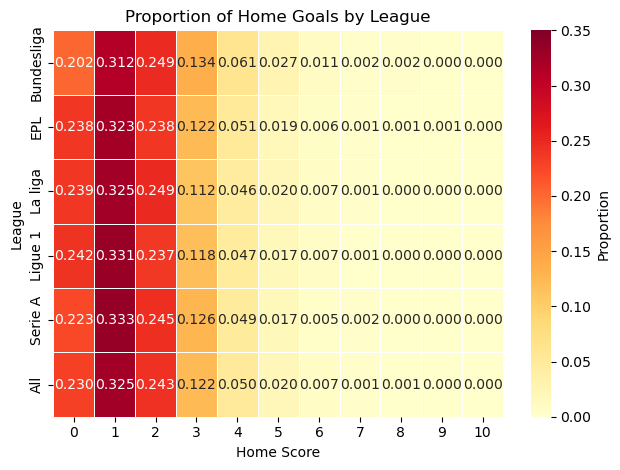

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(
    hsl,
    annot=True,                       # show values
    fmt='.3f',                        # 3 decimal places
    cmap='YlOrRd',                    # color palette (can change to 'coolwarm', etc.)
    linewidths=0.5,                   # cell borders
    cbar_kws={'label': 'Proportion'}, # colorbar label
    vmin=0, vmax=0.35                 # fix color scale for fair comparison
)
plt.title('Proportion of Home Goals by League')
plt.xlabel('Home Score')
plt.ylabel('League')
plt.tight_layout()
plt.show()

In [22]:
pd.crosstab(df['league'], df['away_score'], margins=True, normalize='index')

away_score,0,1,2,3,4,5,6,7,8,9
league,,,,,,,,,,
Bundesliga,0.291213,0.346405,0.202614,0.103486,0.038489,0.011983,0.005447,0.000363,0.000000,0.000000
EPL,0.327778,0.330409,0.201462,0.093860,0.033041,0.009942,0.002632,0.000585,0.000000,0.000292
La liga,0.337427,0.360234,0.198538,0.064035,0.028655,0.007310,0.002924,0.000000,0.000877,0.000000
Ligue 1,0.322483,0.364678,0.192887,0.081977,0.026221,0.009042,0.001206,0.001206,0.000000,0.000301
Serie A,0.289766,0.356433,0.215789,0.092982,0.033626,0.008480,0.001754,0.001170,0.000000,0.000000
All,0.314597,0.351763,0.202302,0.086640,0.031778,0.009246,0.002694,0.000674,0.000184,0.000122


In [23]:

#pd.away_score
#pd.away_xg

# 1. Einfache Pearson-Korrelation (Standard)
correlation = df['away_score'].corr(df['away_xg'])
print(f"Pearson-Korrelation: {correlation:.3f}")

Pearson-Korrelation: 0.635


In [24]:
# 1. Einfache Pearson-Korrelation (Standard)
correlation = df['home_score'].corr(df['home_xg'])
print(f"Pearson-Korrelation: {correlation:.3f}")

Pearson-Korrelation: 0.632


In [25]:
# 2. Spearman-Korrelation (robuster gegenüber Ausreißern)
spearman_corr = df['home_score'].corr(df['home_xg'], method='spearman')
print(f"Spearman-Korrelation: {spearman_corr:.3f}")

Spearman-Korrelation: 0.604


In [26]:
# 2. Spearman-Korrelation (robuster gegenüber Ausreißern)
spearman_corr = df['away_score'].corr(df['away_xg'], method='spearman')
print(f"Spearman-Korrelation: {spearman_corr:.3f}")

Spearman-Korrelation: 0.606


<Axes: xlabel='home_score', ylabel='home_xg'>

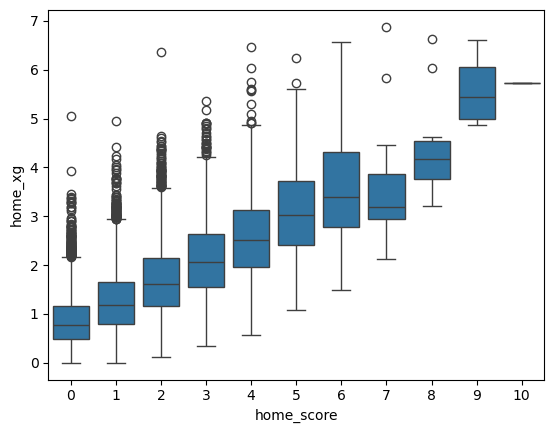

In [27]:
#sns.pairplot(df[['home_score', 'home_xg', 'away_score', 'away_xg']])
sns.boxplot(data=df, x='home_score', y='home_xg')

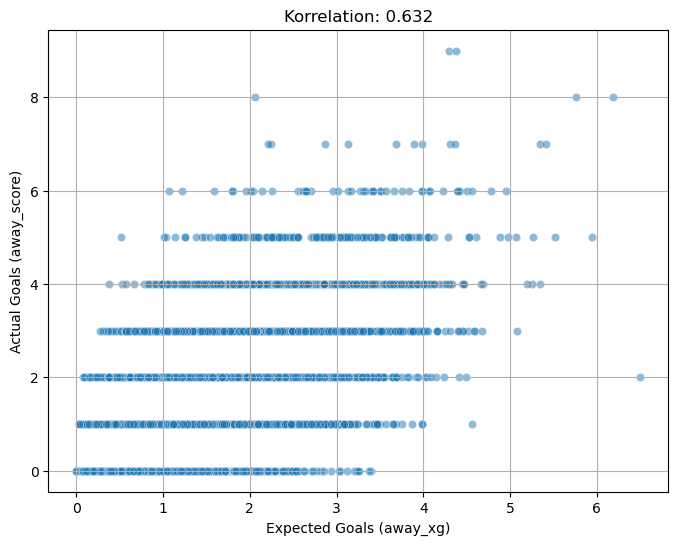

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='away_xg', y='away_score', alpha=0.5)
plt.xlabel('Expected Goals (away_xg)')
plt.ylabel('Actual Goals (away_score)')
plt.title(f'Korrelation: {correlation:.3f}')
plt.grid(True)
plt.show()

In [29]:
df.groupby('home_score')['home_xg'].mean().round(5)

home_score
0     0.87841
1     1.27778
2     1.70184
3     2.14104
4     2.59570
5     3.10410
6     3.60164
7     3.48435
8     4.44000
9     5.59000
10    5.72000
Name: home_xg, dtype: float64

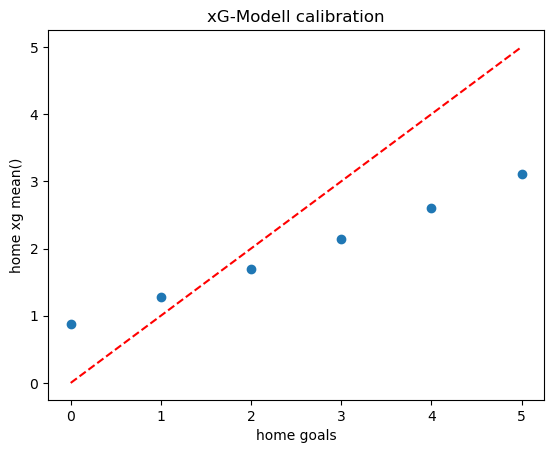

In [30]:
import matplotlib.pyplot as plt

calibration_data = df.groupby('home_score')['home_xg'].mean().reset_index()
filtered_df = calibration_data[calibration_data['home_score'] <= 5]
plt.scatter(filtered_df['home_score'], filtered_df['home_xg'])
plt.plot([0, 5], [0, 5], 'r--')  # Perfekte Kalibrierungslinie
plt.xlabel('home goals')
plt.ylabel('home xg mean()')
plt.title('xG-Modell calibration')
plt.show()

In [31]:
# Daten einschränken
filtered_df = df[df['home_score'] < 6]

# Pearson-Korrelation auf den Rohdaten
corr_raw = filtered_df['home_score'].corr(filtered_df['home_xg'])
print(f"Korrelation (Rohdaten, home_score < 7): {corr_raw:.3f}")

Korrelation (Rohdaten, home_score < 7): 0.606


In [39]:
# Daten einschränken
filtered_df = df[df['home_score'] < 7]

# Gruppieren, mitteln (genau wie gewünscht)  (nicht runden)
grouped = filtered_df.groupby('home_score')['home_xg'].mean()

# In DataFrame umwandeln für Korrelation
plot_df = grouped.reset_index()
plot_df.columns = ['home_score', 'rounded_avg_xg']

# Korrelation berechnen
corr_grouped = plot_df['home_score'].corr(plot_df['rounded_avg_xg'])
print(f"Korrelation (Groupby + round, home_score < 7): {corr_grouped:.4f}")

Korrelation (Groupby + round, home_score < 7): 0.9991


In [36]:
import numpy as np

# Deine Wahrscheinlichkeiten
probs = np.array([0.314597, 0.351763, 0.202302, 0.086640, 0.031778, 0.009246, 0.002694])

# Normalisieren, sodass die Summe exakt 1 wird
probs_norm = probs / np.sum(probs)

# Jetzt funktioniert choice()
goals = [0, 1, 2, 3, 4, 5, 6]
sim_scores = np.random.choice(goals, size=16294, p=probs_norm)


mu = np.sum(goals * probs_norm)  # ergibt 1.2058
sim_const = np.full(10000, mu)
r_const = np.corrcoef(sim_scores, filtered_df.home_score)[0,1]
print(f"Korrelation mit konstantem Mittelwert: {r_const:.3f}")  # -> 0.0 (wegen Rundung evtl. NaN)

Korrelation mit konstantem Mittelwert: -0.004


In [41]:
#clean_df["match_result"].value_counts()
HomeWin =     7270
AwayWin =    4975
Draw =         4087

qw = HomeWin / (HomeWin + AwayWin + Draw)
qA = AwayWin / (HomeWin + AwayWin + Draw)
qD = Draw / (HomeWin + AwayWin + Draw)

print(f"Home Win Probability: {qw:.4f}")
print(f"Away Win Probability: {qA:.4f}")  
print(f"Draw Probability: {qD:.4f}")

Home Win Probability: 0.4451
Away Win Probability: 0.3046
Draw Probability: 0.2502
